  0%|          | 0/30 [00:00<?, ?it/s]

100%|██████████| 30/30 [01:44<00:00,  3.48s/it]
/tmp/ipykernel_3563053/3382265395.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


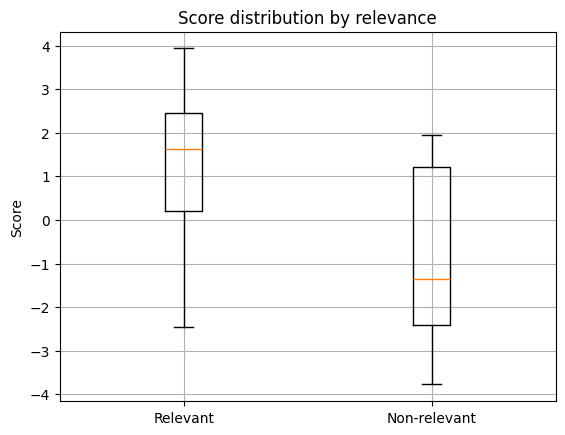

In [4]:
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.path.dirname("."), '..', '..')))
from src.utils.cross_encoder_scorer import CrossEncoderScorer
import pandas as pd
from config.config import STORAGE_DIR
import json
from tqdm import tqdm

# Load cross-encoder model and tokenizer.
reranker_model = AutoModelForSequenceClassification.from_pretrained(
    "/media/discoexterno/leon/legal_ir/results/cross_encoder_lr_1e-05_ranknet/checkpoint-594"
)
tokenizer = AutoTokenizer.from_pretrained(
    "/media/discoexterno/leon/legal_ir/results/cross_encoder_lr_1e-05_ranknet"
)

# Instantiate the scorer.
scorer = CrossEncoderScorer(reranker_model, tokenizer, head_type="ranknet")

# Load qrels.
with open('/media/discoexterno/leon/legal_ir/data/qrels_py.tsv', 'r', encoding='utf-8') as f:
    qrels = pd.read_csv(f, sep="\t", header=None)
    qrels.columns = ["query_id", "_", "doc_id", "relevance"]
    qrels["relevance"] = qrels["relevance"].astype(int)

# Load the corpus dictionary and build the id-to-document mapping.
path = os.path.join(STORAGE_DIR, "legal_ir", "data", "external/BatchAPI_outputs/cleanup/corpus_Gpt4o-mini_cleaned.json")
with open(path, 'r', encoding='utf-8') as f:
    corpus_dict = json.load(f)
    df = pd.DataFrame(list(corpus_dict.items()), columns=["Codigo", "text"])
    doc_ids_all, docs_all = df["Codigo"].tolist(), df["text"].tolist()

id_to_doc = dict(zip(doc_ids_all, docs_all))

# Locate the docs that are in the qrels for query_id 1.
query_id = 1
doc_ids = qrels.loc[qrels["query_id"] == query_id]["doc_id"].tolist()
docs = [id_to_doc[str(doc_id)] for doc_id in doc_ids]

# For one query.
query = "Hurto"

# Calculate scores for the documents.
scores = [scorer.score(query, doc, max_length=4196) for doc in tqdm(docs)]

# Efficiently extract relevances by filtering once:
qrels_query = qrels[qrels["query_id"] == query_id].set_index("doc_id")
relevances = [qrels_query.loc[doc, "relevance"] for doc in doc_ids]

# # Plot the histogram, separating relevant (r>=2) and non-relevant (r<=1).
# plt.hist([s for s, r in zip(scores, relevances) if r >= 2], label='Relevant', alpha=0.6)
# plt.hist([s for s, r in zip(scores, relevances) if r <= 1], label='Non-relevant', alpha=0.6)
# plt.legend()
# plt.title("Score distribution")
# plt.show()

plt.boxplot(
    [ [s for s, r in zip(scores, relevances) if r >= 2],
      [s for s, r in zip(scores, relevances) if r <= 1] ],
    labels=["Relevant", "Non-relevant"]
)
plt.title("Score distribution by relevance")
plt.ylabel("Score")
plt.grid(True)
plt.show()

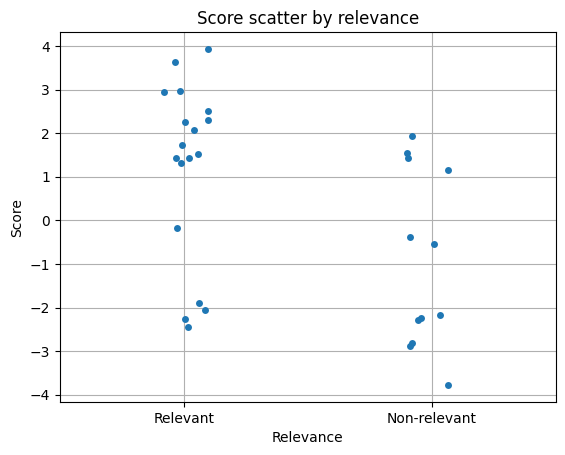

In [5]:
import seaborn as sns
import pandas as pd

df = pd.DataFrame({
    "Score": scores,
    "Relevance": ["Relevant" if r >= 2 else "Non-relevant" for r in relevances]
})

sns.stripplot(data=df, x="Relevance", y="Score", jitter=True)
plt.title("Score scatter by relevance")
plt.grid(True)
plt.show()

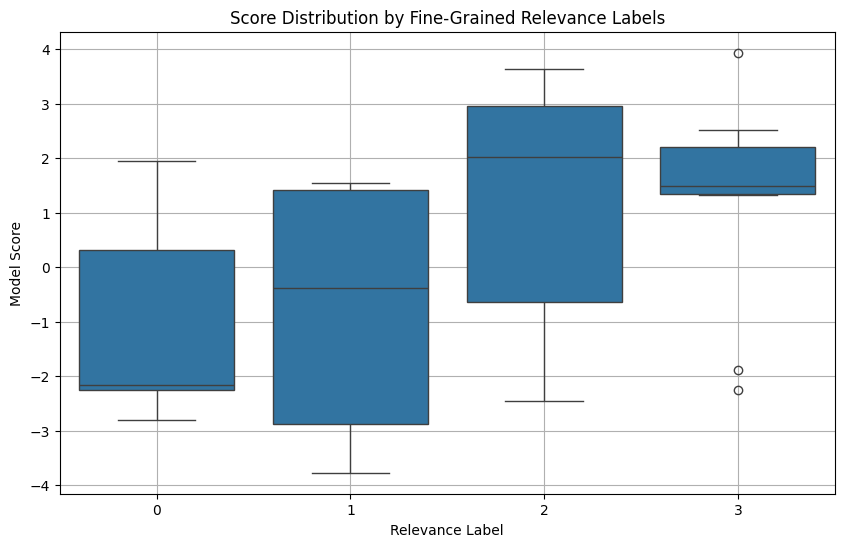

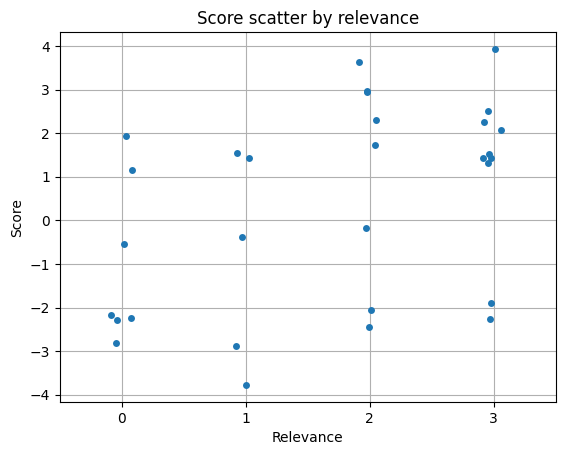

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame with your scores and their fine-grained relevance labels
df = pd.DataFrame({
    "Score": scores,
    "Relevance": relevances  # Each value here is expected to be 0, 1, 2, or 3
})

# Set the figure size for clarity
plt.figure(figsize=(10, 6))

# Plot a boxplot showing the score distribution for each relevance label
sns.boxplot(x="Relevance", y="Score", data=df, order=[0, 1, 2, 3])
plt.title("Score Distribution by Fine-Grained Relevance Labels")
plt.xlabel("Relevance Label")
plt.ylabel("Model Score")
plt.grid(True)
plt.show()

sns.stripplot(data=df, x="Relevance", y="Score", jitter=True)
plt.title("Score scatter by relevance")
plt.grid(True)
plt.show()
